In [30]:
!pip install scikit-learn


[notice] A new release of pip is available: 25.3 -> 26.0
[notice] To update, run: pip install --upgrade pip


In [31]:
import networkx as nx 

In [32]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import sklearn

from skimage.morphology import skeletonize
from skimage.util import img_as_ubyte


In [33]:
from skimage.measure import label
from scipy.ndimage import distance_transform_edt
from sklearn.decomposition import PCA
import networkx as nx
from collections import defaultdict

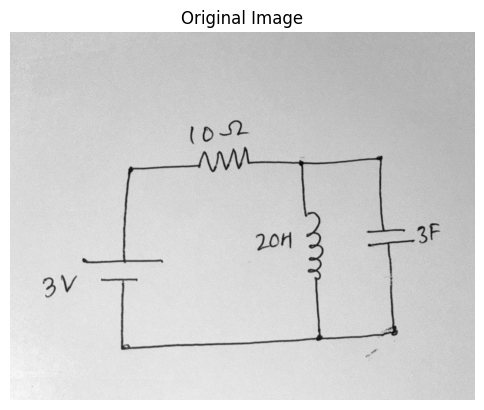

In [34]:
img_path = "/Users/mac/Downloads/LineDetect/ImageData/imgtotest.jpg"

img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

if img is None:
    raise FileNotFoundError(f"Image not found at {img_path}")

plt.figure(figsize=(6,6))
plt.imshow(img, cmap="gray")
plt.title("Original Image")
plt.axis("off")
plt.show()


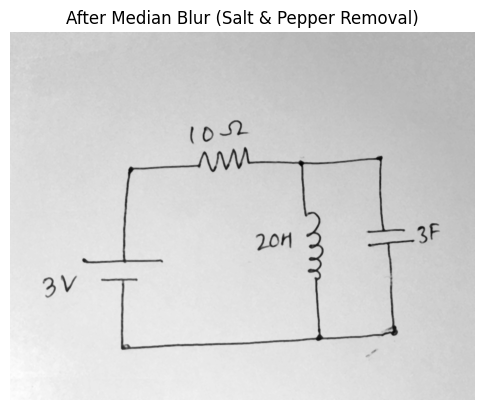

In [35]:
denoised = cv2.medianBlur(img, 5)

plt.figure(figsize=(6,6))
plt.imshow(denoised, cmap="gray")
plt.title("After Median Blur (Salt & Pepper Removal)")
plt.axis("off")
plt.show()


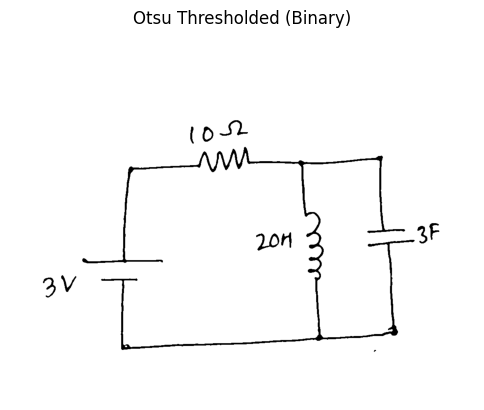

In [36]:
_, otsu_bin = cv2.threshold(denoised, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

plt.figure(figsize=(6,6))
plt.imshow(otsu_bin, cmap="gray")
plt.title("Otsu Thresholded (Binary)")
plt.axis("off")
plt.show()


In [37]:
label_path = "/Users/mac/Downloads/LineDetect/ImageData/imgtotest.txt"
img = otsu_bin
h, w = img.shape

with open(label_path, "r") as f:
    yolo_lines = [ln.strip() for ln in f.readlines() if ln.strip()]



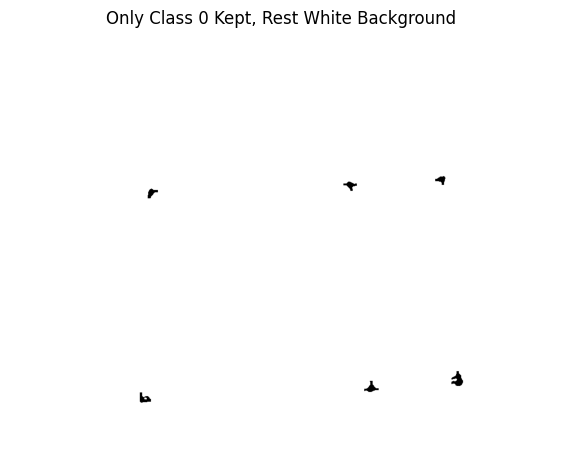

In [38]:
# --- Build mask from YOLO class 0 boxes ---
mask0 = np.zeros((h, w), dtype=np.uint8)

for ln in yolo_lines:
    parts = ln.split()
    if len(parts) < 5:
        continue
    if parts[0] != "1":
        continue

    # take only first 5 values (ignore confidence etc.)
    x, y, bw, bh = map(float, parts[1:5])

    x_center = int(x * w)
    y_center = int(y * h)
    box_w = int(bw * w)
    box_h = int(bh * h)

    x1 = max(0, x_center - box_w // 2)
    y1 = max(0, y_center - box_h // 2)
    x2 = min(w - 1, x_center + box_w // 2)
    y2 = min(h - 1, y_center + box_h // 2)

    cv2.rectangle(mask0, (x1, y1), (x2, y2), 255, thickness=-1)

# --- Keep only class 0 region, make rest white ---
result = np.full_like(img, 255)     # white background
result[mask0 == 255] = img[mask0 == 255]

plt.figure(figsize=(7,7))
plt.imshow(result, cmap="gray")
plt.title("Only Class 0 Kept, Rest White Background")
plt.axis("off")
plt.show()


Processing 14 lines from file...
Successfully removed 8 components. Kept Junctions.


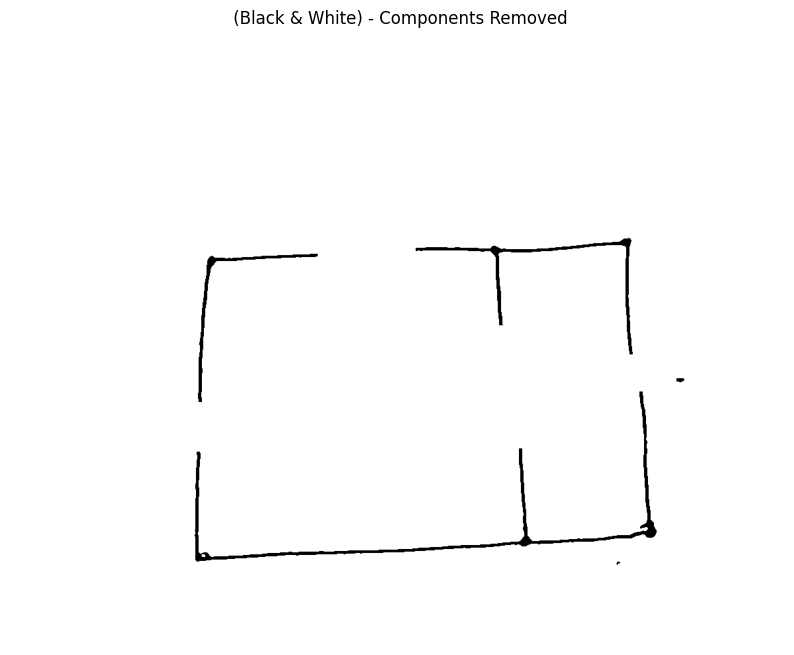

In [39]:
from matplotlib import image


def remove_components(image, label_path):
    # 1. FORCE GRAYSCALE (Black and White)
    # If the image has 3 channels (BGR/RGB), convert to 1 channel (Grayscale)
    cleaned_img = img
    
    # Get image dimensions
    img_h, img_w = cleaned_img.shape[:2]
    
    # 2. DEFINE ERASER FOR GRAYSCALE
    # For single channel images, Black is just 0 (scalar), not a tuple (0,0,0)
    ERASER_COLOR = 255
    
    try:
        with open(label_path, 'r') as f:
            lines = f.readlines()
            
        print(f"Processing {len(lines)} lines from file...")
        
        removed_count = 0
        
        for line in lines:
            parts = line.strip().split()
            if not parts: continue
            
            class_id = int(parts[0])
            
            # LOGIC: If it is NOT a junction (1), remove it
            if class_id != 1:
                # Parse normalized coordinates (0 to 1)
                x_center, y_center = float(parts[1]), float(parts[2])
                box_w, box_h = float(parts[3]), float(parts[4])
                
                # Convert to pixel coordinates
                x1 = int((x_center - box_w / 2) * img_w)
                y1 = int((y_center - box_h / 2) * img_h)
                x2 = int((x_center + box_w / 2) * img_w)
                y2 = int((y_center + box_h / 2) * img_h)
                
                # Clip coordinates
                x1, y1 = max(0, x1), max(0, y1)
                x2, y2 = min(img_w, x2), min(img_h, y2)
                
                # Draw filled black rectangle
                cv2.rectangle(cleaned_img, (x1, y1), (x2, y2), ERASER_COLOR, thickness=-1)
                
                removed_count += 1
                
        print(f"Successfully removed {removed_count} components. Kept Junctions.")
        return cleaned_img

    except FileNotFoundError:
        print(f"Error: The file {label_path} was not found.")
        return image

# --- EXECUTION ---

txt_path = '/Users/mac/Downloads/LineDetect/ImageData/imgtotest.txt'

# Assumes 'img' is already loaded
if 'img' in locals():
    # Run the removal (Returns a Grayscale image)
    masked = remove_components(img, txt_path)

    # 3. Show Result in Black and White
    plt.figure(figsize=(10, 10))
    
    # 'cmap="gray"' ensures it interprets the values as Black/White
    # 'vmin=0, vmax=255' ensures strictly black (0) to white (255) contrast
    plt.imshow(masked, cmap='gray', vmin=0, vmax=255)
    
    plt.title(" (Black & White) - Components Removed")
    plt.axis('off')
    plt.show()
    
    # Save the result as a proper grayscale PNG
    # cv2.imwrite("clean_skeleton_bw.png", final_skeleton)

else:
    print("Please load 'skeleton_img' first.")

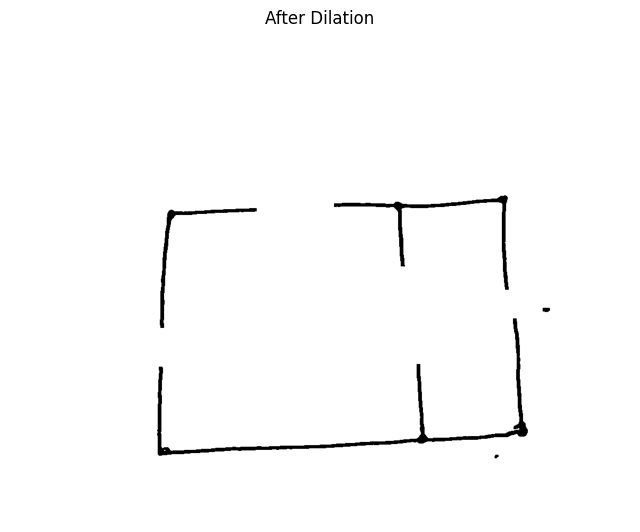

In [40]:
# invert so foreground becomes white for dilation
inv = cv2.bitwise_not(masked)

kernel = np.ones((3, 3), np.uint8)
dilated_inv = cv2.dilate(inv, kernel, iterations=1)

# invert back
dilated = cv2.bitwise_not(dilated_inv)

plt.figure(figsize=(8,8))
plt.imshow(dilated, cmap="gray", vmin=0, vmax=255)
plt.title("After Dilation")
plt.axis("off")
plt.show()


Foreground pixels: 16044
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


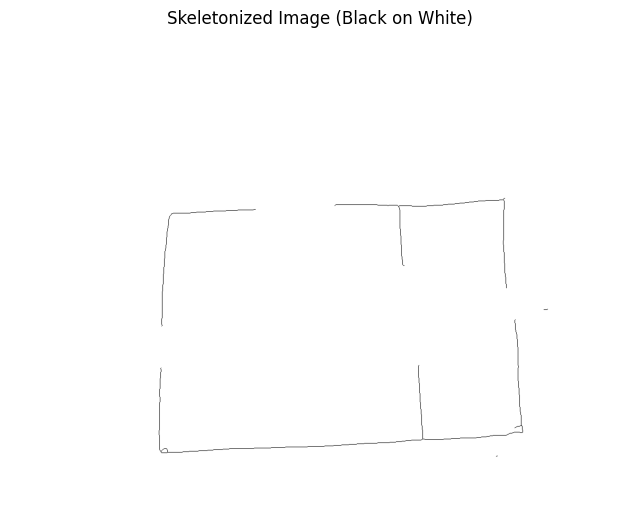

In [41]:
from skimage.morphology import skeletonize
from skimage.util import img_as_ubyte

# Foreground = black pixels
binary = (dilated < 128).astype(np.uint8)   # 1 where black line exists

print("Foreground pixels:", np.sum(binary))

skel = skeletonize(binary).astype(np.uint8)
skel_u8 = img_as_ubyte(skel)

# Convert to black skeleton on white background for display
skel_black_on_white = np.ones_like(dilated) * 255
skel_black_on_white[skel_u8 > 0] = 0
print(skel)

plt.figure(figsize=(8,8))
plt.imshow(skel_black_on_white, cmap="gray", vmin=0, vmax=255)
plt.title("Skeletonized Image (Black on White)")
plt.axis("off")
plt.show()


# Step 1: Parse All Components from Label File

We'll read the YOLO format label file and extract all bounding boxes with their class IDs.
Each line has format: `class_id x_center y_center width height [confidence]`

- Coordinates are normalized (0-1), so we multiply by image dimensions
- We store: class_id, center pixel coordinates, and bounding box corners

In [42]:
# Parse all components from the label file
# Each component will be stored as a dictionary with its properties

label_path = "/Users/mac/Downloads/LineDetect/ImageData/imgtotest.txt"

# Get image dimensions from the skeleton (skel is from previous cell)
img_h, img_w = skel.shape

def parse_yolo_labels(label_path, img_w, img_h):
    """
    Parse YOLO format labels and convert to pixel coordinates.
    
    YOLO format: class_id x_center y_center width height [confidence]
    - All coordinates are normalized (0 to 1)
    - x_center, y_center: center of bounding box
    - width, height: size of bounding box
    
    Returns: List of dictionaries with component info
    """
    components = []
    
    with open(label_path, 'r') as f:
        lines = f.readlines()
    
    for idx, line in enumerate(lines):
        parts = line.strip().split()
        if len(parts) < 5:
            continue
        
        # Extract values
        class_id = int(parts[0])
        x_norm, y_norm = float(parts[1]), float(parts[2])
        w_norm, h_norm = float(parts[3]), float(parts[4])
        confidence = float(parts[5]) if len(parts) > 5 else 1.0
        
        # Convert normalized coords to pixel coords
        x_center = int(x_norm * img_w)
        y_center = int(y_norm * img_h)
        box_w = int(w_norm * img_w)
        box_h = int(h_norm * img_h)
        
        # Calculate bounding box corners
        x1 = max(0, x_center - box_w // 2)
        y1 = max(0, y_center - box_h // 2)
        x2 = min(img_w - 1, x_center + box_w // 2)
        y2 = min(img_h - 1, y_center + box_h // 2)
        
        component = {
            'index': idx,
            'class_id': class_id,
            'center': (x_center, y_center),  # (x, y) pixel coords
            'bbox': (x1, y1, x2, y2),         # (x1, y1, x2, y2)
            'confidence': confidence
        }
        components.append(component)
    
    return components

# Parse all components
all_components = parse_yolo_labels(label_path, img_w, img_h)

# Separate Class 0 (blobs) from other components
class_0_components = [c for c in all_components if c['class_id'] == 0]
other_components = [c for c in all_components if c['class_id'] != 0]

print(f"Total components found: {len(all_components)}")
print(f"Class 0 (blobs/starting points): {len(class_0_components)}")
print(f"Other components (targets): {len(other_components)}")
print("\n--- Class 0 Components (Starting Points) ---")
for c in class_0_components:
    print(f"  Index {c['index']}: Center={c['center']}, BBox={c['bbox']}")
print("\n--- Other Components (Targets) ---")
for c in other_components:
    print(f"  Index {c['index']}: Class={c['class_id']}, Center={c['center']}")

Total components found: 14
Class 0 (blobs/starting points): 4
Other components (targets): 10

--- Class 0 Components (Starting Points) ---
  Index 10: Center=(1052, 504), BBox=(1021, 476, 1083, 532)
  Index 11: Center=(530, 249), BBox=(450, 216, 610, 282)
  Index 12: Center=(124, 638), BBox=(79, 606, 169, 670)
  Index 13: Center=(664, 525), BBox=(614, 499, 714, 551)

--- Other Components (Targets) ---
  Index 0: Class=1, Center=(779, 767)
  Index 1: Class=1, Center=(931, 316)
  Index 2: Class=1, Center=(733, 328)
  Index 3: Class=1, Center=(287, 792)
  Index 4: Class=1, Center=(304, 344)
  Index 5: Class=1, Center=(968, 750)
  Index 6: Class=12, Center=(281, 596)
  Index 7: Class=9, Center=(539, 318)
  Index 8: Class=15, Center=(764, 535)
  Index 9: Class=12, Center=(950, 515)


# Step 2: Find Nearest Skeleton Pixel

For each component, we need to find the nearest pixel that lies ON the skeleton.
- The skeleton is stored in `skel` (1 = skeleton pixel, 0 = background)
- We use Euclidean distance to find the closest skeleton pixel to the bounding box center
- This will be our starting/ending point for pathfinding

In [43]:
def find_nearest_skeleton_pixel(point, skeleton):
    """
    Find the nearest skeleton pixel to a given point.
    
    Parameters:
    - point: tuple (x, y) in pixel coordinates
    - skeleton: 2D numpy array where 1 = skeleton pixel, 0 = background
    
    Returns:
    - (x, y) coordinates of nearest skeleton pixel
    - distance to that pixel
    
    Method:
    1. Get all skeleton pixel coordinates
    2. Calculate Euclidean distance from point to each skeleton pixel
    3. Return the one with minimum distance
    """
    x, y = point
    
    # Get all skeleton pixel locations
    # np.where returns (row_indices, col_indices) = (y_coords, x_coords)
    skel_y, skel_x = np.where(skeleton == 1)
    
    if len(skel_x) == 0:
        print("Warning: No skeleton pixels found!")
        return None, float('inf')
    
    # Calculate Euclidean distance to each skeleton pixel
    # Distance formula: sqrt((x2-x1)^2 + (y2-y1)^2)
    distances = np.sqrt((skel_x - x)**2 + (skel_y - y)**2)
    
    # Find index of minimum distance
    min_idx = np.argmin(distances)
    
    # Get the nearest skeleton pixel coordinates
    nearest_x = skel_x[min_idx]
    nearest_y = skel_y[min_idx]
    min_distance = distances[min_idx]
    
    return (nearest_x, nearest_y), min_distance

# Find nearest skeleton pixel for each component
print("Finding nearest skeleton pixels for all components...")
print("=" * 60)

for component in all_components:
    center = component['center']
    nearest_pixel, distance = find_nearest_skeleton_pixel(center, skel)
    
    # Store in component dictionary for later use
    component['skeleton_point'] = nearest_pixel
    component['skeleton_distance'] = distance
    
    print(f"Component {component['index']} (Class {component['class_id']}):")
    print(f"  Center: {center}")
    print(f"  Nearest skeleton pixel: {nearest_pixel}")
    print(f"  Distance: {distance:.2f} pixels")
    print()

Finding nearest skeleton pixels for all components...
Component 0 (Class 1):
  Center: (779, 767)
  Nearest skeleton pixel: (np.int64(779), np.int64(767))
  Distance: 0.00 pixels

Component 1 (Class 1):
  Center: (931, 316)
  Nearest skeleton pixel: (np.int64(932), np.int64(316))
  Distance: 1.00 pixels

Component 2 (Class 1):
  Center: (733, 328)
  Nearest skeleton pixel: (np.int64(732), np.int64(329))
  Distance: 1.41 pixels

Component 3 (Class 1):
  Center: (287, 792)
  Nearest skeleton pixel: (np.int64(286), np.int64(791))
  Distance: 1.41 pixels

Component 4 (Class 1):
  Center: (304, 344)
  Nearest skeleton pixel: (np.int64(305), np.int64(344))
  Distance: 1.00 pixels

Component 5 (Class 1):
  Center: (968, 750)
  Nearest skeleton pixel: (np.int64(967), np.int64(750))
  Distance: 1.00 pixels

Component 6 (Class 12):
  Center: (281, 596)
  Nearest skeleton pixel: (np.int64(285), np.int64(635))
  Distance: 39.20 pixels

Component 7 (Class 9):
  Center: (539, 318)
  Nearest skeleton

# Visualize Nearest Skeleton Pixels

Let's plot the results to verify that we found the correct nearest skeleton pixels:
- Gray skeleton pixels
- Component centers marked with colored circles (different color per class)
- Nearest skeleton pixels marked with squares
- Lines connecting each center to its nearest skeleton pixel

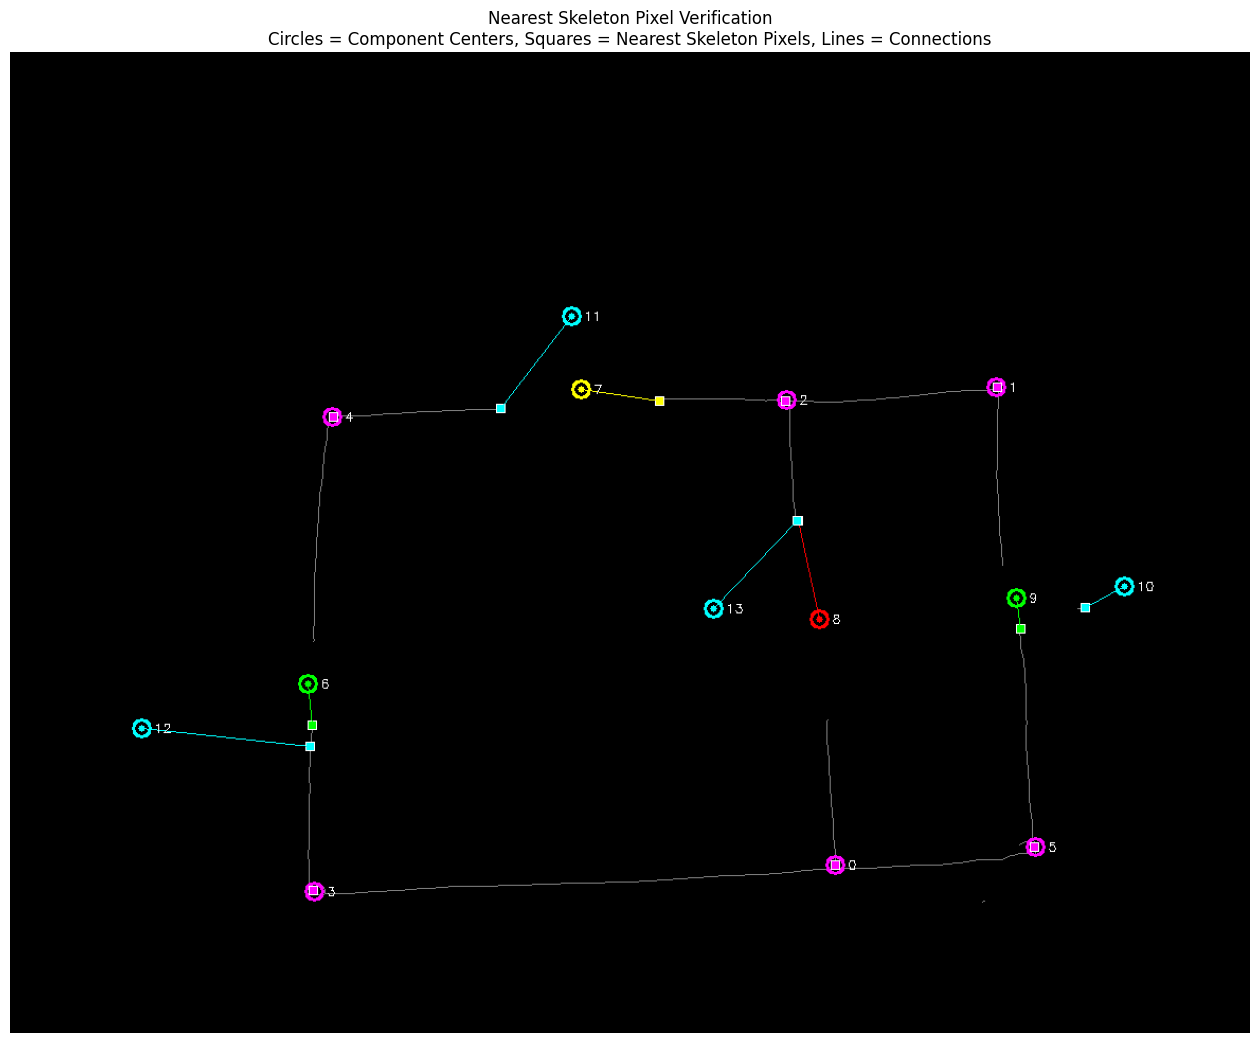


COMPONENT VERIFICATION SUMMARY:
Comp  Class  Center (x,y)    Skeleton (x,y)  Distance   Color     
----------------------------------------------------------------------
0     1      (779, 767)      (779, 767)      0.0        Magenta   
1     1      (931, 316)      (932, 316)      1.0        Magenta   
2     1      (733, 328)      (732, 329)      1.4        Magenta   
3     1      (287, 792)      (286, 791)      1.4        Magenta   
4     1      (304, 344)      (305, 344)      1.0        Magenta   
5     1      (968, 750)      (967, 750)      1.0        Magenta   
6     12     (281, 596)      (285, 635)      39.2       Green     
7     9      (539, 318)      (613, 329)      74.8       Yellow    
8     15     (764, 535)      (744, 442)      95.1       Red       
9     12     (950, 515)      (954, 544)      29.3       Green     
10    0      (1052, 504)     (1015, 524)     42.1       Cyan      
11    0      (530, 249)      (463, 336)      109.8      Cyan      
12    0      (124, 638)  

In [58]:
# Create visualization to verify nearest skeleton pixel detection

# Create a color image for visualization
vis_img = np.zeros((skel.shape[0], skel.shape[1], 3), dtype=np.uint8)

# Draw skeleton in gray
vis_img[skel == 1] = [128, 128, 128]  # Gray skeleton pixels

# Define colors for different classes
class_colors = {
    0: [0, 255, 255],    # Cyan for Class 0 (blobs)
    1: [255, 0, 255],    # Magenta for Class 1 (junctions)
    9: [255, 255, 0],    # Yellow for Class 9
    12: [0, 255, 0],     # Green for Class 12
    15: [255, 0, 0],     # Red for Class 15
}

# Process each component
for comp in all_components:
    center = comp['center']
    skeleton_point = comp['skeleton_point']
    class_id = comp['class_id']
    
    # Get color for this class (default to white if class not in our color map)
    color = class_colors.get(class_id, [255, 255, 255])
    
    if skeleton_point is not None:
        # Draw component center as a circle
        cv2.circle(vis_img, center, 8, color, 2)  # Colored circle outline
        cv2.circle(vis_img, center, 3, color, -1)  # Small filled center
        
        # Draw nearest skeleton pixel as a square
        x, y = skeleton_point
        # Create a small square around the skeleton pixel
        square_size = 4
        cv2.rectangle(vis_img, 
                     (x - square_size, y - square_size), 
                     (x + square_size, y + square_size), 
                     color, -1)
        cv2.rectangle(vis_img, 
                     (x - square_size, y - square_size), 
                     (x + square_size, y + square_size), 
                     [255, 255, 255], 1)  # White border
        
        # Draw line connecting center to nearest skeleton pixel
        cv2.line(vis_img, center, skeleton_point, color, 1)
        
        # Add component index text near the center
        text_pos = (center[0] + 12, center[1] + 4)
        cv2.putText(vis_img, str(comp['index']), text_pos, 
                   cv2.FONT_HERSHEY_SIMPLEX, 0.4, [255, 255, 255], 1)

# Display the visualization
plt.figure(figsize=(16, 16))
plt.imshow(vis_img)
plt.title("Nearest Skeleton Pixel Verification\n" +
          "Circles = Component Centers, Squares = Nearest Skeleton Pixels, Lines = Connections")
plt.axis("off")
plt.show()

# Create legend
print("\nCOMPONENT VERIFICATION SUMMARY:")
print("=" * 70)
print(f"{'Comp':<5} {'Class':<6} {'Center (x,y)':<15} {'Skeleton (x,y)':<15} {'Distance':<10} {'Color':<10}")
print("-" * 70)

for comp in all_components:
    center = comp['center']
    skeleton_point = comp['skeleton_point']
    distance = comp['skeleton_distance']
    class_id = comp['class_id']
    
    center_str = f"({center[0]}, {center[1]})"
    skeleton_str = f"({skeleton_point[0]}, {skeleton_point[1]})" if skeleton_point else "None"
    distance_str = f"{distance:.1f}" if skeleton_point else "N/A"
    
    # Color name mapping
    color_names = {0: "Cyan", 1: "Magenta", 9: "Yellow", 12: "Green", 15: "Red"}
    color_name = color_names.get(class_id, "White")
    
    print(f"{comp['index']:<5} {class_id:<6} {center_str:<15} {skeleton_str:<15} {distance_str:<10} {color_name:<10}")

print("=" * 70)

# Summary by class
print("\nCLASS SUMMARY:")
print("-" * 30)
class_counts = {}
for comp in all_components:
    class_id = comp['class_id']
    class_counts[class_id] = class_counts.get(class_id, 0) + 1

for class_id, count in sorted(class_counts.items()):
    color_names = {0: "Cyan", 1: "Magenta", 9: "Yellow", 12: "Green", 15: "Red"}
    color_name = color_names.get(class_id, "White")
    print(f"Class {class_id}: {count} components ({color_name})")

print(f"\nTotal: {len(all_components)} components")

# Check for any components that couldn't find skeleton pixels
no_skeleton = [comp for comp in all_components if comp['skeleton_point'] is None]
if no_skeleton:
    print(f"\nWARNING: {len(no_skeleton)} components couldn't find nearby skeleton pixels!")
    for comp in no_skeleton:
        print(f"  Component {comp['index']} (Class {comp['class_id']}) at {comp['center']}")
else:
    print("\n✓ All components successfully found nearest skeleton pixels!")

# Step 3: Implement BFS Pathfinding with 8-Connectivity

BFS (Breadth-First Search) algorithm:
1. Start from a source pixel on the skeleton
2. Explore all 8 neighbors (including diagonals)
3. Only move to pixels that are ON the skeleton (value = 1)
4. Keep track of visited pixels to avoid cycles
5. Store parent of each pixel to reconstruct path
6. Stop when we reach the target pixel

**8-Connectivity Directions:**
```
(-1,-1) (-1,0) (-1,1)
(0,-1)   [X]   (0,1)
(1,-1)  (1,0)  (1,1)
```

In [55]:
from collections import deque

def bfs_pathfinding(skeleton, start, end):
    """
    Find shortest path between two points on the skeleton using BFS.
    
    Parameters:
    - skeleton: 2D numpy array (1 = walkable skeleton pixel, 0 = background)
    - start: tuple (x, y) starting pixel coordinates
    - end: tuple (x, y) ending pixel coordinates
    
    Returns:
    - path: list of (x, y) coordinates from start to end, or None if no path
    - visited_count: number of pixels explored during search
    
    Algorithm Steps:
    1. Initialize queue with start position
    2. For each position, check all 8 neighbors
    3. If neighbor is on skeleton and not visited, add to queue
    4. Track parent of each pixel to reconstruct path
    5. When end is found, backtrack through parents to get path
    """
    
    # 8-connectivity: all 8 directions (including diagonals)
    # Format: (delta_x, delta_y)
    DIRECTIONS_8 = [
        (-1, -1), (-1, 0), (-1, 1),  # top-left, top, top-right
        (0, -1),           (0, 1),   # left, right
        (1, -1),  (1, 0),  (1, 1)    # bottom-left, bottom, bottom-right
    ]
    
    # Get skeleton dimensions
    height, width = skeleton.shape
    
    # Validate start and end points
    start_x, start_y = start
    end_x, end_y = end
    
    # Check if start/end are within bounds
    if not (0 <= start_x < width and 0 <= start_y < height):
        print(f"  Error: Start point {start} is out of bounds")
        return None, 0
    if not (0 <= end_x < width and 0 <= end_y < height):
        print(f"  Error: End point {end} is out of bounds")
        return None, 0
    
    # Check if start/end are on the skeleton
    if skeleton[start_y, start_x] != 1:
        print(f"  Error: Start point {start} is not on skeleton")
        return None, 0
    if skeleton[end_y, end_x] != 1:
        print(f"  Error: End point {end} is not on skeleton")
        return None, 0
    
    # If start equals end, return immediately
    if start == end:
        return [start], 1
    
    # BFS data structures
    queue = deque([start])           # Queue of positions to explore
    visited = {start}                 # Set of visited positions
    parent = {start: None}            # Dictionary to track path: child -> parent
    
    visited_count = 0
    
    while queue:
        current = queue.popleft()
        current_x, current_y = current
        visited_count += 1
        # print(visited_count)
        
        # Check all 8 neighbors
        for dx, dy in DIRECTIONS_8:
            next_x = current_x + dx
            next_y = current_y + dy
            next_pos = (next_x, next_y)
            
            # Skip if out of bounds
            if not (0 <= next_x < width and 0 <= next_y < height):
                continue
            
            # Skip if already visited
            if next_pos in visited:
                continue
            
            # Skip if not on skeleton (can only walk on skeleton pixels)
            if skeleton[next_y, next_x] != 1:
                continue
            
            # Mark as visited and record parent
            visited.add(next_pos)
            parent[next_pos] = current
            
            # Check if we reached the destination
            if next_pos == end:
                # Reconstruct path by backtracking through parents
                path = []
                pos = end
                while pos is not None:
                    path.append(pos)
                    pos = parent[pos]
                path.reverse()  # Reverse to get start -> end order
                return path, visited_count
                
            
            # Add to queue for further exploration
            queue.append(next_pos)
    
    # No path found
    return None, visited_count

# Test the BFS function with a simple example
print("BFS Pathfinding function defined successfully!")
print("\nFunction signature: bfs_pathfinding(skeleton, start, end)")
print("Returns: (path_as_list_of_coordinates, visited_count)")

BFS Pathfinding function defined successfully!

Function signature: bfs_pathfinding(skeleton, start, end)
Returns: (path_as_list_of_coordinates, visited_count)


# Step 4: Run Pathfinding from Each Class 0 to All Other Components

For each Class 0 blob (starting point):
1. Get its nearest skeleton pixel (source)
2. For each other component (including other Class 0s):
   - Get the target's nearest skeleton pixel
   - Run BFS to find path
   - If path exists, record it as a "line"
3. Store results with:
   - Start coordinates
   - End coordinates  
   - Full path (list of coordinates)
   - Path length

In [56]:
# Run pathfinding from each Class 0 to all other components
# Store results in a list of dictionaries

detected_lines = []

print("=" * 70)
print("PATHFINDING: From Each Class 0 to All Other Components")
print("=" * 70)

for source_component in class_0_components:
    source_idx = source_component['index']
    source_start = source_component['skeleton_point']
    
    if source_start is None:
        print(f"\nSkipping Component {source_idx}: No skeleton point found")
        continue
    
    print(f"\n{'='*60}")
    print(f"SOURCE: Component {source_idx} (Class 0)")
    print(f"  Original center: {source_component['center']}")
    print(f"  Skeleton start point: {source_start}")
    print(f"{'='*60}")
    
    # Try to find path to every other component
    for target_component in all_components:
        target_idx = target_component['index']
        
        # Skip if same component
        if target_idx == source_idx:
            continue
        
        target_end = target_component['skeleton_point']
        
        if target_end is None:
            print(f"\n  → Target {target_idx}: No skeleton point, skipping")
            continue
        
        print(f"\n  → Searching path to Component {target_idx} (Class {target_component['class_id']})...")
        print(f"    Target skeleton point: {target_end}")
        
        # Run BFS pathfinding
        path, visited_count = bfs_pathfinding(skel, source_start, target_end)
        
        if path is not None:
            path_length = len(path)
            print(f"    ✓ PATH FOUND!")
            print(f"      Path length: {path_length} pixels")
            print(f"      Pixels explored: {visited_count}")
            print(f"      Start coord: {path[0]}")
            print(f"      End coord: {path[-1]}")
            
            # Store the detected line
            line_info = {
                'source_index': source_idx,
                'source_class': source_component['class_id'],
                'source_center': source_component['center'],
                'source_skeleton_point': source_start,
                'target_index': target_idx,
                'target_class': target_component['class_id'],
                'target_center': target_component['center'],
                'target_skeleton_point': target_end,
                'path': path,
                'path_length': path_length,
                'start_coord': path[0],
                'end_coord': path[-1]
            }
            detected_lines.append(line_info)
        else:
            print(f"    ✗ No path found (explored {visited_count} pixels)")

print(f"\n{'='*70}")
print(f"SUMMARY: Found {len(detected_lines)} paths/lines")
print(f"{'='*70}")

PATHFINDING: From Each Class 0 to All Other Components

SOURCE: Component 10 (Class 0)
  Original center: (1052, 504)
  Skeleton start point: (np.int64(1015), np.int64(524))

  → Searching path to Component 0 (Class 1)...
    Target skeleton point: (np.int64(779), np.int64(767))
    ✗ No path found (explored 8 pixels)

  → Searching path to Component 1 (Class 1)...
    Target skeleton point: (np.int64(932), np.int64(316))
    ✗ No path found (explored 8 pixels)

  → Searching path to Component 2 (Class 1)...
    Target skeleton point: (np.int64(732), np.int64(329))
    ✗ No path found (explored 8 pixels)

  → Searching path to Component 3 (Class 1)...
    Target skeleton point: (np.int64(286), np.int64(791))
    ✗ No path found (explored 8 pixels)

  → Searching path to Component 4 (Class 1)...
    Target skeleton point: (np.int64(305), np.int64(344))
    ✗ No path found (explored 8 pixels)

  → Searching path to Component 5 (Class 1)...
    Target skeleton point: (np.int64(967), np.in

# Step 5: Display Results Summary

Show all detected lines in a table format with:
- Source component info (index, class, coordinates)
- Target component info (index, class, coordinates)
- Path length

In [57]:
# Display results in a clean table format
print("DETECTED LINES SUMMARY")
print("=" * 100)
print(f"{'#':<4} {'Source':<25} {'Target':<25} {'Start Coord':<15} {'End Coord':<15} {'Length':<8}")
print("-" * 100)

for i, line in enumerate(detected_lines):
    source_info = f"Comp {line['source_index']} (Class {line['source_class']})"
    target_info = f"Comp {line['target_index']} (Class {line['target_class']})"
    start = f"({line['start_coord'][0]}, {line['start_coord'][1]})"
    end = f"({line['end_coord'][0]}, {line['end_coord'][1]})"
    
    print(f"{i+1:<4} {source_info:<25} {target_info:<25} {start:<15} {end:<15} {line['path_length']:<8}")

print("=" * 100)

# Also create a structured data output
print("\n\nDETAILED LINE INFORMATION:")
print("-" * 60)
for i, line in enumerate(detected_lines):
    print(f"\nLine {i+1}:")
    print(f"  From: Component {line['source_index']} (Class {line['source_class']})")
    print(f"    Center: {line['source_center']}")
    print(f"    Skeleton Point: {line['source_skeleton_point']}")
    print(f"  To: Component {line['target_index']} (Class {line['target_class']})")
    print(f"    Center: {line['target_center']}")
    print(f"    Skeleton Point: {line['target_skeleton_point']}")
    print(f"  Path:")
    print(f"    Start: {line['start_coord']}")
    print(f"    End: {line['end_coord']}")
    print(f"    Length: {line['path_length']} pixels")
    # Show first and last few path coordinates
    if line['path_length'] > 6:
        print(f"    Coordinates (first 3): {line['path'][:3]}")
        print(f"    Coordinates (last 3): {line['path'][-3:]}")
    else:
        print(f"    Full path: {line['path']}")

DETECTED LINES SUMMARY
#    Source                    Target                    Start Coord     End Coord       Length  
----------------------------------------------------------------------------------------------------
1    Comp 11 (Class 0)         Comp 4 (Class 1)          (463, 336)      (305, 344)      159     
2    Comp 12 (Class 0)         Comp 0 (Class 1)          (283, 655)      (779, 767)      636     
3    Comp 12 (Class 0)         Comp 3 (Class 1)          (283, 655)      (286, 791)      140     
4    Comp 12 (Class 0)         Comp 5 (Class 1)          (283, 655)      (967, 750)      829     
5    Comp 12 (Class 0)         Comp 6 (Class 12)         (283, 655)      (285, 635)      21      
6    Comp 12 (Class 0)         Comp 9 (Class 12)         (283, 655)      (954, 544)      1035    
7    Comp 13 (Class 0)         Comp 1 (Class 1)          (743, 442)      (932, 316)      311     
8    Comp 13 (Class 0)         Comp 2 (Class 1)          (743, 442)      (732, 329)      114

# Step 6: Visualize the Paths on the Skeleton

Draw all detected paths on the skeleton image:
- Skeleton in gray
- Each path in a different color
- Mark start points (Class 0) with green circles
- Mark end points (targets) with red circles

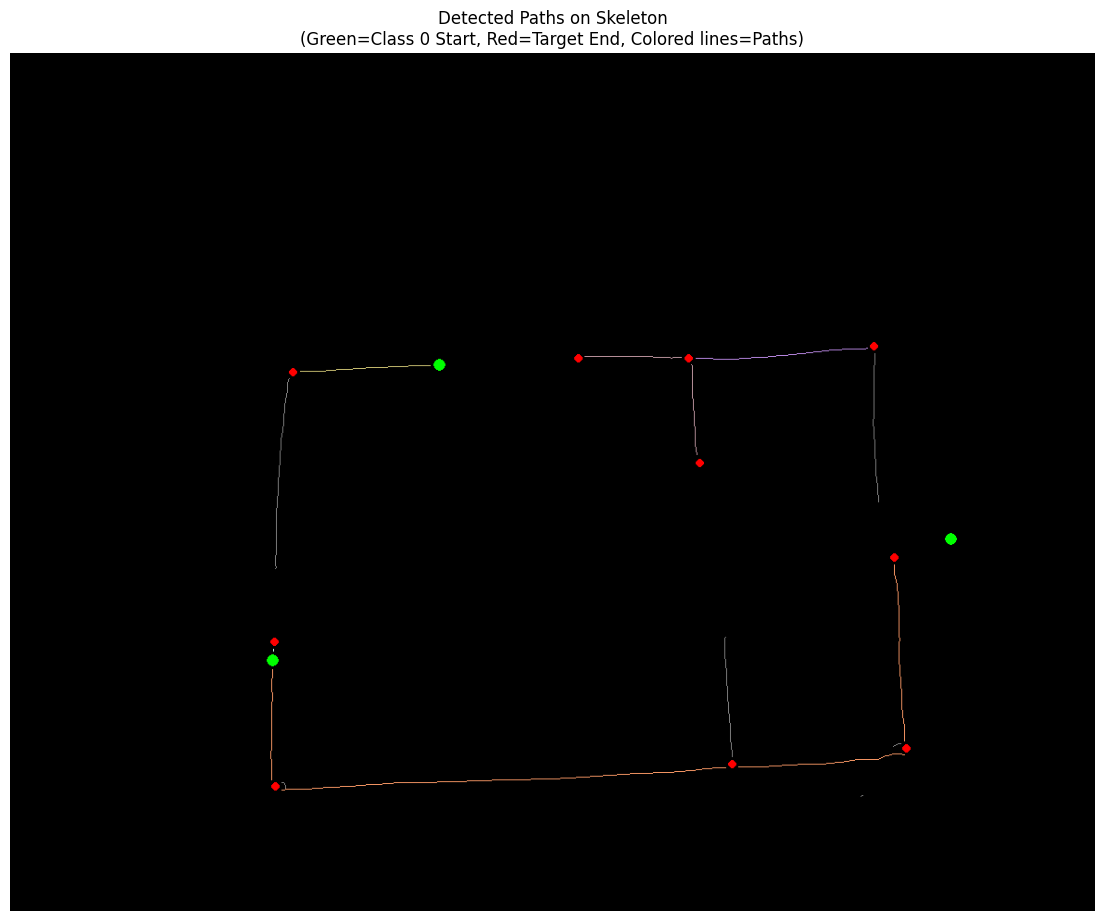


COLOR LEGEND:
----------------------------------------
● Green circles: Class 0 starting points
● Red circles: Target component points
● Gray: Skeleton pixels
● Colored paths: Detected lines/paths
  Path 1: Component 11 → Component 4
  Path 2: Component 12 → Component 0
  Path 3: Component 12 → Component 3
  Path 4: Component 12 → Component 5
  Path 5: Component 12 → Component 6
  Path 6: Component 12 → Component 9
  Path 7: Component 13 → Component 1
  Path 8: Component 13 → Component 2
  Path 9: Component 13 → Component 7
  Path 10: Component 13 → Component 8


In [47]:
# Visualize all detected paths on the skeleton

# Create a color image for visualization (RGB)
# Start with skeleton as grayscale background
vis_img = np.zeros((skel.shape[0], skel.shape[1], 3), dtype=np.uint8)

# Draw skeleton in gray
vis_img[skel == 1] = [128, 128, 128]  # Gray skeleton

# Generate distinct colors for each path
np.random.seed(42)  # For reproducibility
colors = []
for i in range(len(detected_lines)):
    # Generate random bright colors
    color = [np.random.randint(100, 255) for _ in range(3)]
    colors.append(color)

# Draw each path
for idx, line in enumerate(detected_lines):
    path = line['path']
    color = colors[idx]
    
    # Draw path pixels
    for (x, y) in path:
        vis_img[y, x] = color

# Draw start points (Class 0 skeleton points) - GREEN circles
for comp in class_0_components:
    if comp['skeleton_point'] is not None:
        x, y = comp['skeleton_point']
        cv2.circle(vis_img, (x, y), 8, (0, 255, 0), -1)  # Green filled circle
        cv2.circle(vis_img, (x, y), 8, (0, 0, 0), 2)     # Black border

# Draw target points - RED circles
for comp in other_components:
    if comp['skeleton_point'] is not None:
        x, y = comp['skeleton_point']
        cv2.circle(vis_img, (x, y), 6, (255, 0, 0), -1)  # Red filled circle
        cv2.circle(vis_img, (x, y), 6, (0, 0, 0), 2)     # Black border

# Display
plt.figure(figsize=(14, 14))
plt.imshow(vis_img)
plt.title("Detected Paths on Skeleton\n(Green=Class 0 Start, Red=Target End, Colored lines=Paths)")
plt.axis("off")
plt.show()

# Legend
print("\nCOLOR LEGEND:")
print("-" * 40)
print("● Green circles: Class 0 starting points")
print("● Red circles: Target component points")
print("● Gray: Skeleton pixels")
print("● Colored paths: Detected lines/paths")
for idx, line in enumerate(detected_lines):
    print(f"  Path {idx+1}: Component {line['source_index']} → Component {line['target_index']}")

# Step 7: Export Path Coordinates

Save all detected line information to a structured format that you can use later.
This includes the complete list of coordinates for each path.

In [48]:
# Export path coordinates to a Python dictionary/list structure
# You can also save this to a JSON file if needed

import json

# Create exportable data structure
export_data = {
    'image_dimensions': {'width': img_w, 'height': img_h},
    'total_lines_detected': len(detected_lines),
    'lines': []
}

for idx, line in enumerate(detected_lines):
    line_export = {
        'line_id': idx + 1,
        'source': {
            'component_index': line['source_index'],
            'class_id': line['source_class'],
            'center': list(line['source_center']),
            'skeleton_point': list(line['source_skeleton_point'])
        },
        'target': {
            'component_index': line['target_index'],
            'class_id': line['target_class'],
            'center': list(line['target_center']),
            'skeleton_point': list(line['target_skeleton_point'])
        },
        'path': {
            'start_coord': list(line['start_coord']),
            'end_coord': list(line['end_coord']),
            'length_pixels': line['path_length'],
            'coordinates': [list(coord) for coord in line['path']]
        }
    }
    export_data['lines'].append(line_export)

# Print the structured data
print("EXPORTABLE DATA STRUCTURE:")
print("=" * 60)
print(f"Total lines: {export_data['total_lines_detected']}")
print(f"Image size: {export_data['image_dimensions']}")
print("\nSample of first line's path coordinates:")
if export_data['lines']:
    first_line = export_data['lines'][0]
    coords = first_line['path']['coordinates']
    print(f"  Total coordinates in path: {len(coords)}")
    print(f"  First 5 coordinates: {coords[:5]}")
    print(f"  Last 5 coordinates: {coords[-5:]}")

# Optionally save to JSON file
# output_path = "/Users/mac/Downloads/LineDetect/detected_lines.json"
# with open(output_path, 'w') as f:
#     json.dump(export_data, f, indent=2)
# print(f"\nData saved to: {output_path}")

# The 'detected_lines' list and 'export_data' dict are now available for further use
print("\n\nVariables available for further processing:")
print("  - detected_lines: List of dictionaries with all path info")
print("  - export_data: JSON-exportable dictionary structure")

EXPORTABLE DATA STRUCTURE:
Total lines: 10
Image size: {'width': 1171, 'height': 926}

Sample of first line's path coordinates:
  Total coordinates in path: 159
  First 5 coordinates: [[np.int64(463), np.int64(336)], [np.int64(462), np.int64(336)], [np.int64(461), np.int64(336)], [np.int64(460), np.int64(336)], [np.int64(459), np.int64(337)]]
  Last 5 coordinates: [[np.int64(309), np.int64(343)], [np.int64(308), np.int64(343)], [np.int64(307), np.int64(344)], [np.int64(306), np.int64(344)], [np.int64(305), np.int64(344)]]


Variables available for further processing:
  - detected_lines: List of dictionaries with all path info
  - export_data: JSON-exportable dictionary structure


In [49]:
import json
from pathlib import Path

json_path = Path("/Users/mac/Downloads/LineDetect/end_coordinates.json")

with open(json_path, "r") as f:
    end_coords = json.load(f)

len(end_coords), end_coords[:5]


(10, [[305, 344], [779, 767], [286, 791], [967, 750], [285, 635]])